# Detecting robotic grasping points using Keypoint R-CNN

#### Set up

In [1]:
# install packages
# pip install pycocotools
# pip install labelme

In [2]:
# import packages
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

### 1. Explore and prepare the dataset

In [ ]:
# inspect data
data_root = Path("Data/broccoli") 

In [4]:
# inspect train and test split
splits = ["train", "val", "test"]

print("\nSplit:")
split_stats = {}
for split in splits:
    split_dir = data_root / split
    images = sorted(split_dir.glob("*.png"))
    split_stats[split] = {"images": len(images)}
    print(f"  {split:}: {len(images)} images")


Split:
  train: 963 images
  val: 305 images
  test: 345 images


In [ ]:
# Inspect annotation 
with open("Data/broccoli/train/20200713_10103484155_plant1001_rgb_trigger002.json") as f:
    ann = json.load(f)
print("Just a annotation to inspect: ", ann)

for split in ["train", "val", "test"]:
    json_files = sorted((data_root / split).glob("*.json"))[:2] # first 2 from each set
    for jpath in json_files:
        with open(jpath) as f:
            ann = json.load(f)
        print(f"\nSample: {split}/{jpath.name}")
        print(f"Size: {ann['imageWidth']} x {ann['imageHeight']}")
        print(f"Shapes: {len(ann['shapes'])}")
        for s in ann["shapes"]:
            print(f"{s['label']:>10}{s['shape_type']}{s['points']}")


Just a annotation to inspect:  {'version': '4.5.6', 'flags': {}, 'shapes': [{'label': 'broccoli', 'line_color': None, 'fill_color': None, 'points': [[677, 659], [677, 768]], 'shape_type': 'circle', 'flags': {}}], 'lineColor': [0, 255, 0, 128], 'fillColor': [255, 0, 0, 128], 'imagePath': '20200713_10103484155_plant1001_rgb_trigger002.png', 'imageData': None, 'imageHeight': 1280, 'imageWidth': 1280}

Sample: train/20200713_10103484155_plant1001_rgb_trigger002.json
Size: 1280 x 1280
Shapes: 1
  broccolicircle[[677, 659], [677, 768]]

Sample: train/20200713_101111109942_plant1001_rgb_trigger003.json
Size: 1280 x 1280
Shapes: 1
  broccolicircle[[677, 659], [677, 768]]

Sample: val/20200713_103058583358_plant1005_rgb_trigger001.json
Size: 1280 x 1280
Shapes: 1
  broccolicircle[[761, 672], [761, 789]]

Sample: val/20200713_103127777800_plant1005_rgb_trigger004.json
Size: 1280 x 1280
Shapes: 1
  broccolicircle[[761, 672], [761, 789]]

Sample: test/20200713_102404448731_plant1003_rgb_trigger002

{"version": "4.5.6", "flags": {}, "shapes": [{"label": "broccoli", "line_color": null, "fill_color": null, "points": [[677, 659], [677, 768]], "shape_type": "circle", "flags": {}}], "lineColor": [0, 255, 0, 128], "fillColor": [255, 0, 0, 128], "imagePath": "20200713_10103484155_plant1001_rgb_trigger002.png", "imageData": null, "imageHeight": 1280, "imageWidth": 1280}

The annotation uses a circle shape type, where:
- [677, 659] — the center of the broccoli
- [677, 768] — a point on the edge, which defines the radius (768 - 659 = 109 pixels)

So 1 broccoli

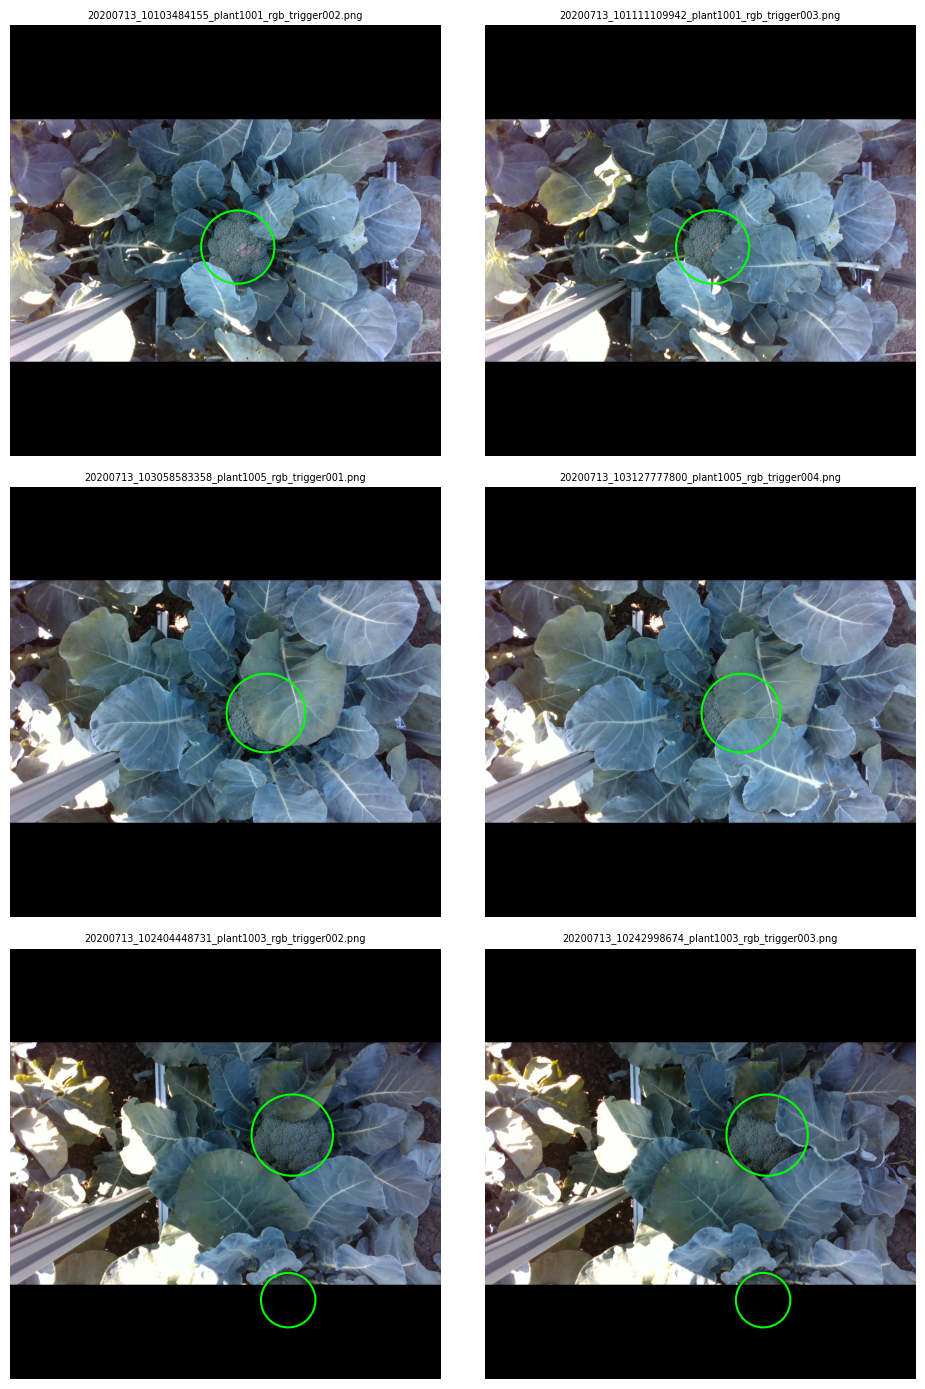

In [6]:
# Inspect images
fig, axes = plt.subplots(3, 2, figsize=(10, 14))

for row, split in enumerate(["train", "val", "test"]):
    for col, img_path in enumerate(sorted((data_root / split).glob("*.png"))[:2]):
        ann = json.load(open(img_path.with_suffix(".json")))
        ax = axes[row, col]
        ax.imshow(Image.open(img_path))
        ax.set_title(img_path.name, fontsize=7)
        ax.axis("off")

        for s in ann["shapes"]:
            (cx, cy), (ex, ey) = s["points"]
            radius = np.sqrt((ex - cx)**2 + (ey - cy)**2)
            ax.add_patch(patches.Circle((cx, cy), radius, linewidth=1.5,
                                         edgecolor="lime", facecolor="none"))

plt.tight_layout()
plt.show()


Dit gaf AI nog als recommendations, niet zelf geprogrammeerd.

In [7]:
# Count labels
label_counts = defaultdict(lambda: defaultdict(int))

for split in splits:
    for jpath in (data_root / split).glob("*.json"):
        with open(jpath) as f:
            data = json.load(f)
        for shape in data.get("shapes", []):
            label_counts[split][shape["label"]] += 1

print("\n── Label counts per split ──")
all_labels = sorted({lbl for s in label_counts.values() for lbl in s})
header = f"{'label':>20}" + "".join(f"  {s:>6}" for s in splits)
print(header)
for lbl in all_labels:
    row = f"{lbl:>20}" + "".join(f"  {label_counts[s].get(lbl,0):>6}" for s in splits)
    print(row)


── Label counts per split ──
               label   train     val    test
            broccoli    1184     347     394


### 2. Custom Dataloader

### 3. Model Architecture

### 4. Training and Evaluation

### 5. Debugging